# Customer segmentation for targeted marketing campaigns

In [3]:
"""
1 Importing libraries
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [4]:
"""
2 Loading the CSV Dataset
"""

file_path = "https://raw.githubusercontent.com/Alessio8-ai/Project-files/refs/heads/main/"

# We load data into a DataFrame
df = pd.read_csv(file_path+"credit_card_customers.csv")

print("Dataset loaded successfully!")

# Dataset size
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully!
The dataset contains 8950 rows and 18 columns.


In [5]:
"""
3 Inspecting the Dataset to Understand What Information I Have Available
"""

# View first 5 rows
print("--- FIRST 5 ROWS OF THE DATASET ---")
display(df.head())

# Column names and initial data types
print("\n--- INFORMATION ABOUT COLUMNS ---")
df.info()


--- FIRST 5 ROWS OF THE DATASET ---


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12



--- INFORMATION ABOUT COLUMNS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  

In [6]:
# Descriptive statistics of the dataset
print("--- STATISTICAL ANALYSIS ---")
df.describe()

--- STATISTICAL ANALYSIS ---


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [7]:
"""
4 Preprocessing - Identifying Missing Values, Duplicates, and Anomalies
"""

# Identifying missing values ​​for each column
print("Missing values ​​per column:")
print(df.isnull().sum())

# We replace the missing values ​​with the median of the respective column
# We use the median because it is more robust than the mean in the presence of anomalies.
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

# We also replace the missing value in CREDIT_LIMIT.
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

print("\nCheck after cleaning (they must all be 0):")
print(df.isnull().sum())

Missing values ​​per column:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Check after cleaning (they must all be 0):
CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INST

In [8]:
# Check and remove duplicates
duplicate_values = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_values}")

# If the result is greater than 0, we delete them:
if duplicate_values > 0:
    df = df.drop_duplicates()
    print("Duplicate rows successfully removed!")

Number of duplicate rows found: 0


In [9]:
"""
5 Data Standardization
"""

# We create an independent copy of the cleaned dataset
df_clustering = df.copy()

# From now on we only work on the 'df_clustering' copy
# We save the CUST_IDs in a separate series for future reference.
customer_ids = df_clustering['CUST_ID']

# We create the feature set excluding the CUST_ID column
X = df_clustering.drop(columns=['CUST_ID'])

# Let's initialize the StandardScaler
scaler = StandardScaler()

# We adapt the scaler to the data and transform the values
X_scaled = scaler.fit_transform(X)

# Let's convert the result into a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Copy created and data standardized successfully!")
print(f"Original dataset 'df' preserved with {df.shape[1]} columns.")
print(f"Clustering dataset 'X_scaled_df' ready with {X_scaled_df.shape[1]} columns.")
print("--- STANDARDIZED DATASET ---")
display(X_scaled_df.head())

Copy created and data standardized successfully!
Original dataset 'df' preserved with 18 columns.
Clustering dataset 'X_scaled_df' ready with 17 columns.
--- STANDARDIZED DATASET ---


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


In [10]:
"""
6 Let's find the number of Clusters
"""

RANDOM_SEED = 2
X = X_scaled_df

In [11]:
# Calculating Inertia for Different Values ​​of K
def plot_ssd_curve(X_scaled_df):

  # We test the algorithm with a number of clusters ranging from 1 to 10
  ssd = {}
  for k in range(1, 11):
      # We initialize K-Means and train the algorithm on standardized data.
      kmeans = KMeans(init="k-means++", n_init=10, n_clusters=k, random_state=RANDOM_SEED).fit(X_scaled_df)
      ssd[k] = kmeans.inertia_

  # Let's plot the elbow using matplotlib
  plt.figure(figsize=(8, 5))
  plt.plot(list(ssd.keys()), list(ssd.values()),marker="o")
  plt.title("Elbow Method for determining ideal K")
  plt.xlabel("Number of clusters", fontsize=12)
  plt.ylabel("Inertia (WCSS)", fontsize=12)
  plt.grid(True)
  plt.show()

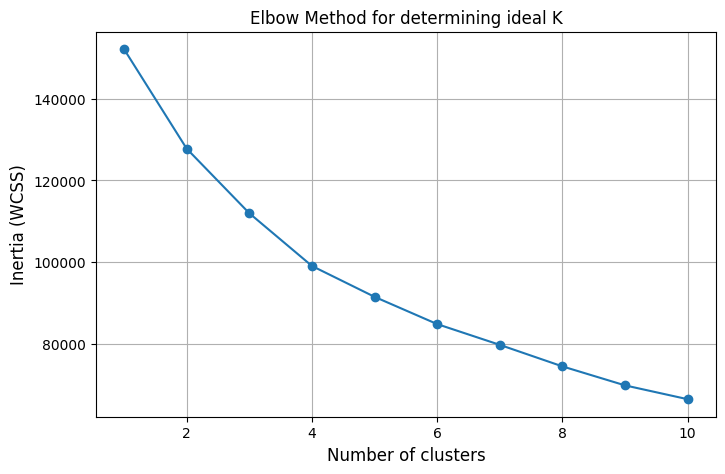

In [12]:
plot_ssd_curve(X)

In [13]:
"""
7 Final training with K=4 and cluster assignment
"""

# We initialize the final model with 4 clusters
final_kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)

# We train the model on SCALED data and predict clusters
cluster_labels = final_kmeans.fit_predict(X_scaled_df)

# Let's add the 'Cluster' column to our COPY of the original dataset
df_clustering["Cluster"] = cluster_labels

# Let's see how many customers ended up in each group
print("Distribution of customers in the 4 clusters:")
print(df_clustering["Cluster"].value_counts().sort_index())

print("\nPreview the dataset with the new Cluster column:")
df_clustering[["CUST_ID", "BALANCE", "PURCHASES", "Cluster"]].head()

Distribution of customers in the 4 clusters:
Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64

Preview the dataset with the new Cluster column:


,CUST_ID,BALANCE,PURCHASES,Cluster
0,C10001,40.900749,95.40,0
1,C10002,3202.467416,0.00,2
2,C10003,2495.148862,773.17,3
3,C10004,1666.670542,1499.00,0
4,C10005,817.714335,16.00,0


In [14]:
"""
8 Creating the average profile of each cluster
"""

# We group by the 'Cluster' column and calculate the average of all numeric columns
# We exclude CUST_ID because it is a text and cannot be averaged.
cluster_profile = df_clustering.drop(columns=["CUST_ID"]).groupby("Cluster").mean()

# We also add a row to the table that tells us how many customers there are in each group.
cluster_profile["Dimensione_Cluster"] = df_clustering["Cluster"].value_counts()

# We show the table "rotated" for better reading, formatting the numbers with 3 decimal places.
cluster_profile.T.style.format("{:.3f}")

Cluster,0,1,2,3
BALANCE,1012.658,3551.154,4602.450,894.907
BALANCE_FREQUENCY,0.790,0.987,0.968,0.935
PURCHASES,270.042,7681.620,501.863,1236.179
ONEOFF_PURCHASES,209.937,5095.879,320.189,593.975
INSTALLMENTS_PURCHASES,60.371,2587.208,181.759,642.478
CASH_ADVANCE,596.510,653.639,4521.510,210.571
PURCHASES_FREQUENCY,0.170,0.946,0.288,0.885
ONEOFF_PURCHASES_FREQUENCY,0.086,0.739,0.139,0.297
PURCHASES_INSTALLMENTS_FREQUENCY,0.081,0.788,0.186,0.712
CASH_ADVANCE_FREQUENCY,0.115,0.071,0.485,0.043


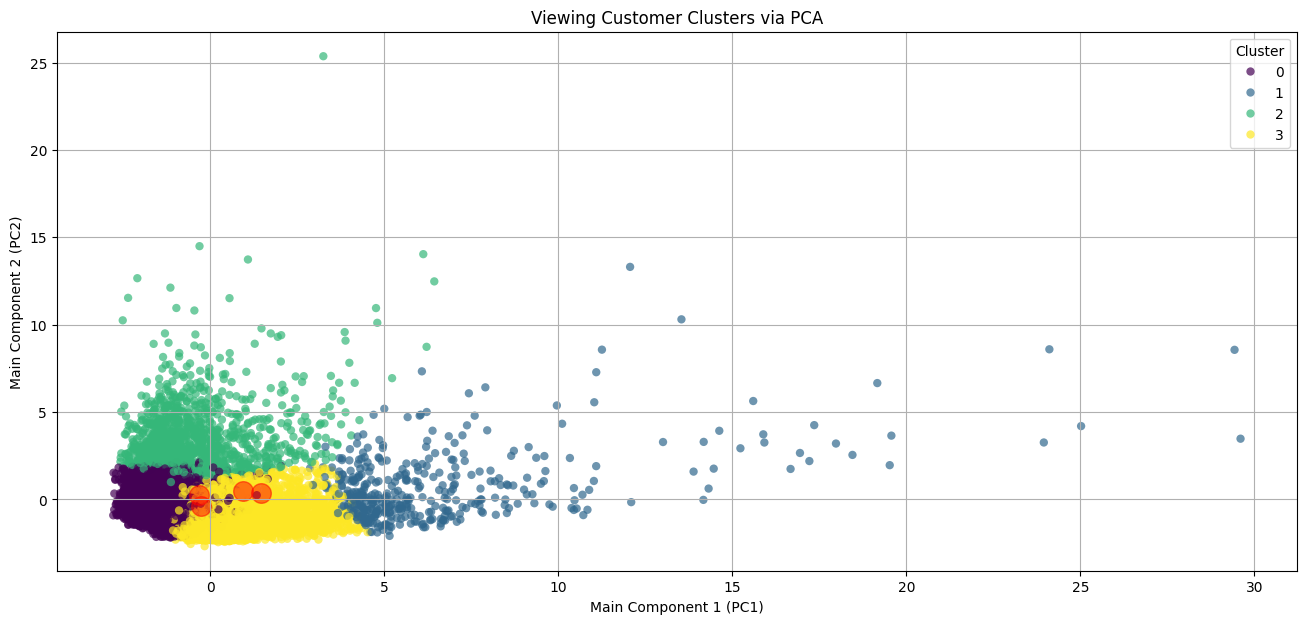

In [15]:
"""
9 Dimension reduction with PCA and Scatter Plot
"""

# We initialize the PCA by saying that we want to reduce everything to just 2 components
pca = PCA(n_components=2, random_state=RANDOM_SEED)

# We apply PCA on standardized data
X_pca = pca.fit_transform(X_scaled_df)

# Let's create a new temporary DataFrame for the chart
df_pca = pd.DataFrame(data=X_pca, columns=["Component_1", "Component_2"])

# Let's add the Cluster column to this DataFrame to be able to color the points
df_pca["Cluster"] = df_clustering["Cluster"]

# Let's draw the Scatter Plot with Seaborn
plt.figure(figsize=(16, 7))

# sns.scatterplot plots the points
sns.scatterplot(
    x="Component_1",
    y="Component_2",
    hue="Cluster",
    palette="viridis",
    data=df_pca,
    alpha=0.7,
    edgecolor="none"
)

# We use final_kmeans.cluster_centers_ to access cluster centers
new_var = plt.scatter(final_kmeans.cluster_centers_[:, 0], final_kmeans.cluster_centers_[:, 1], c="red", s=200, alpha=0.5)
new_var

plt.title("Viewing Customer Clusters via PCA")
plt.xlabel("Main Component 1 (PC1)")
plt.ylabel("Main Component 2 (PC2)")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

In [16]:
"""
10 Creating the final file for the marketing team
"""

# We create a dictionary to "translate" cluster numbers into real business names

cluster_names = {
    0: "Installment Payers",
    1: "Big Spenders",
    2: "Cash Advance Users",
    3: "Occasional Customers"
}

# Let's create a new DataFrame with only the essential information
df_result = pd.DataFrame({
    "CUST_ID": df_clustering["CUST_ID"],
    "ID_Cluster": df_clustering["Cluster"]
})

# We apply the translation using Pandas' .map() method
df_result["Marketing_Segment"] = df_result["ID_Cluster"].map(cluster_names)

# We save the result to a new CSV file in a local Colab file
df_result.to_csv("segmented_marketing_customers.csv")

print(f"The final file was saved successfully")
print("\n File Preview:")
df_result.head(10)

The final file was saved successfully

 File Preview:


,CUST_ID,ID_Cluster,Marketing_Segment
0,C10001,0,Installment Payers
1,C10002,2,Cash Advance Users
2,C10003,3,Occasional Customers
3,C10004,0,Installment Payers
4,C10005,0,Installment Payers
5,C10006,3,Occasional Customers
6,C10007,1,Big Spenders
7,C10008,3,Occasional Customers
8,C10009,0,Installment Payers
9,C10010,0,Installment Payers


# Marketing Strategy Development

0. Installment Payers

Identikit: Purchase focused almost entirely on installment transactions (INSTALLMENTS_PURCHASES).

Marketing Action:

- Establish specific partnerships with large electronics chains, furniture, or travel, offering "interest-free installment payments" for purchases over a certain threshold made with their card.

- Send instant in-app notifications when they make a single purchase over €100, offering a quick button to convert it into 3 or 6 convenient installments.
------

1. Big Spenders

Identikit: Customers with a high spending limit, high balance, frequent and expensive purchases.

Marketing Action:

- Offer a free upgrade to a higher tier card (e.g. Gold or Platinum).

- Activate a premium Cashback program (e.g., earn points or get a 1% cashback on all purchases).

- Invite to exclusive events or give priority access to luxury partnerships.
-----

2. Cash Advance Users

Identikit: They use the card very little in stores, but they use it constantly to withdraw cash at the ATM.

Marketing Action:

- Send communications explaining the benefits and security of direct digital payments (e.g., "Did you know there are no fees for paying in stores by card?").

- Offer offers that encourage card use (e.g., discounts, Amazon vouchers, and Cashback).
------

3. Occasional Customers

Identikit: Balance near zero, very few purchases per year. They risk abandoning the card.

Marketing Action:

- Send an offer like, "Spend at least €50 by the end of the month and receive a €10 Amazon voucher" to encourage them to put their card back in their wallet.

- Conduct targeted email surveys to understand if they avoid using cards due to high fixed costs or if they prefer another payment method.